### Dataset Loading

In [8]:
import pandas as pd

gym_dataset = pd.read_csv("gym_members_exercise_tracking.csv")

gym_dataset_copy = gym_dataset.copy()
gym_dataset_copy.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


### Removing False Predictors

In [9]:
gym_dataset_copy = gym_dataset_copy.drop(['Calories_Burned'], axis=1)

gym_dataset_copy = gym_dataset_copy.drop(['Max_BPM'], axis=1)

### Data Vizualization

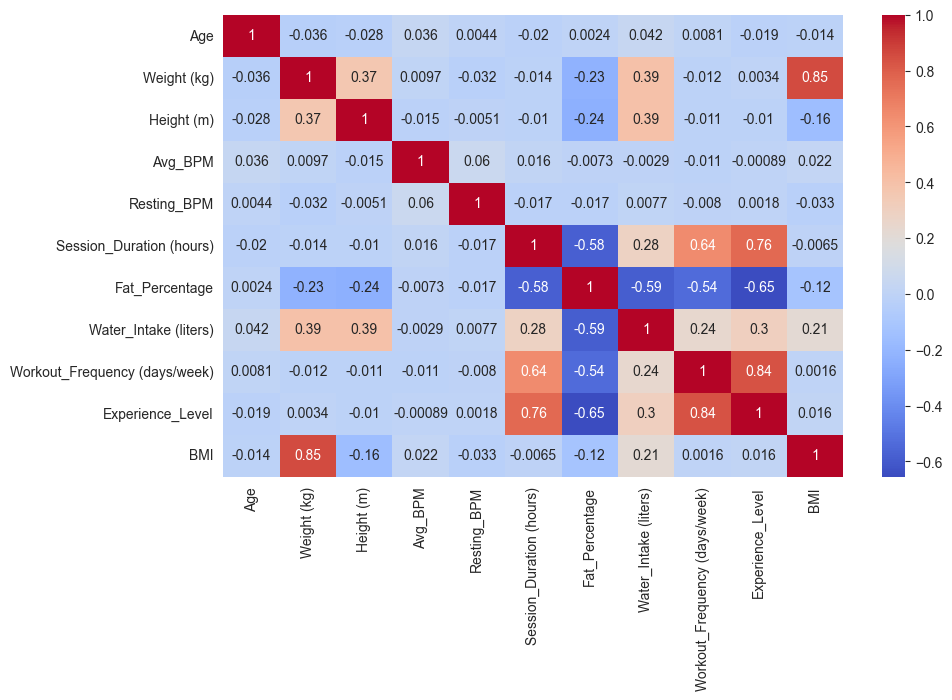

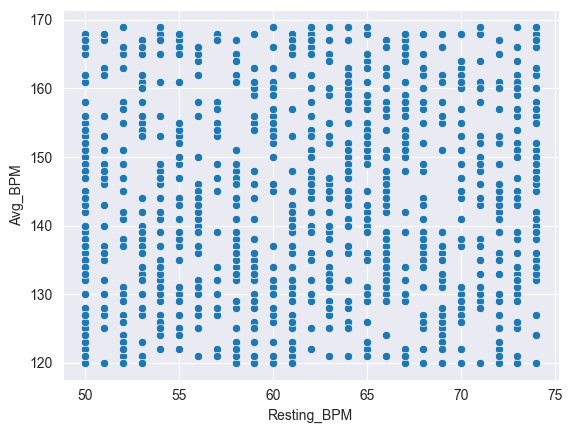

In [10]:
import seaborn as sb
import matplotlib.pyplot as plt

# correlation
plt.figure(figsize=(10, 6))
sb.heatmap(gym_dataset_copy.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# relationship between Resting_BPM and Avg_BPM
sb.scatterplot(data=gym_dataset_copy, x='Resting_BPM', y='Avg_BPM')
plt.show()

### Outliers

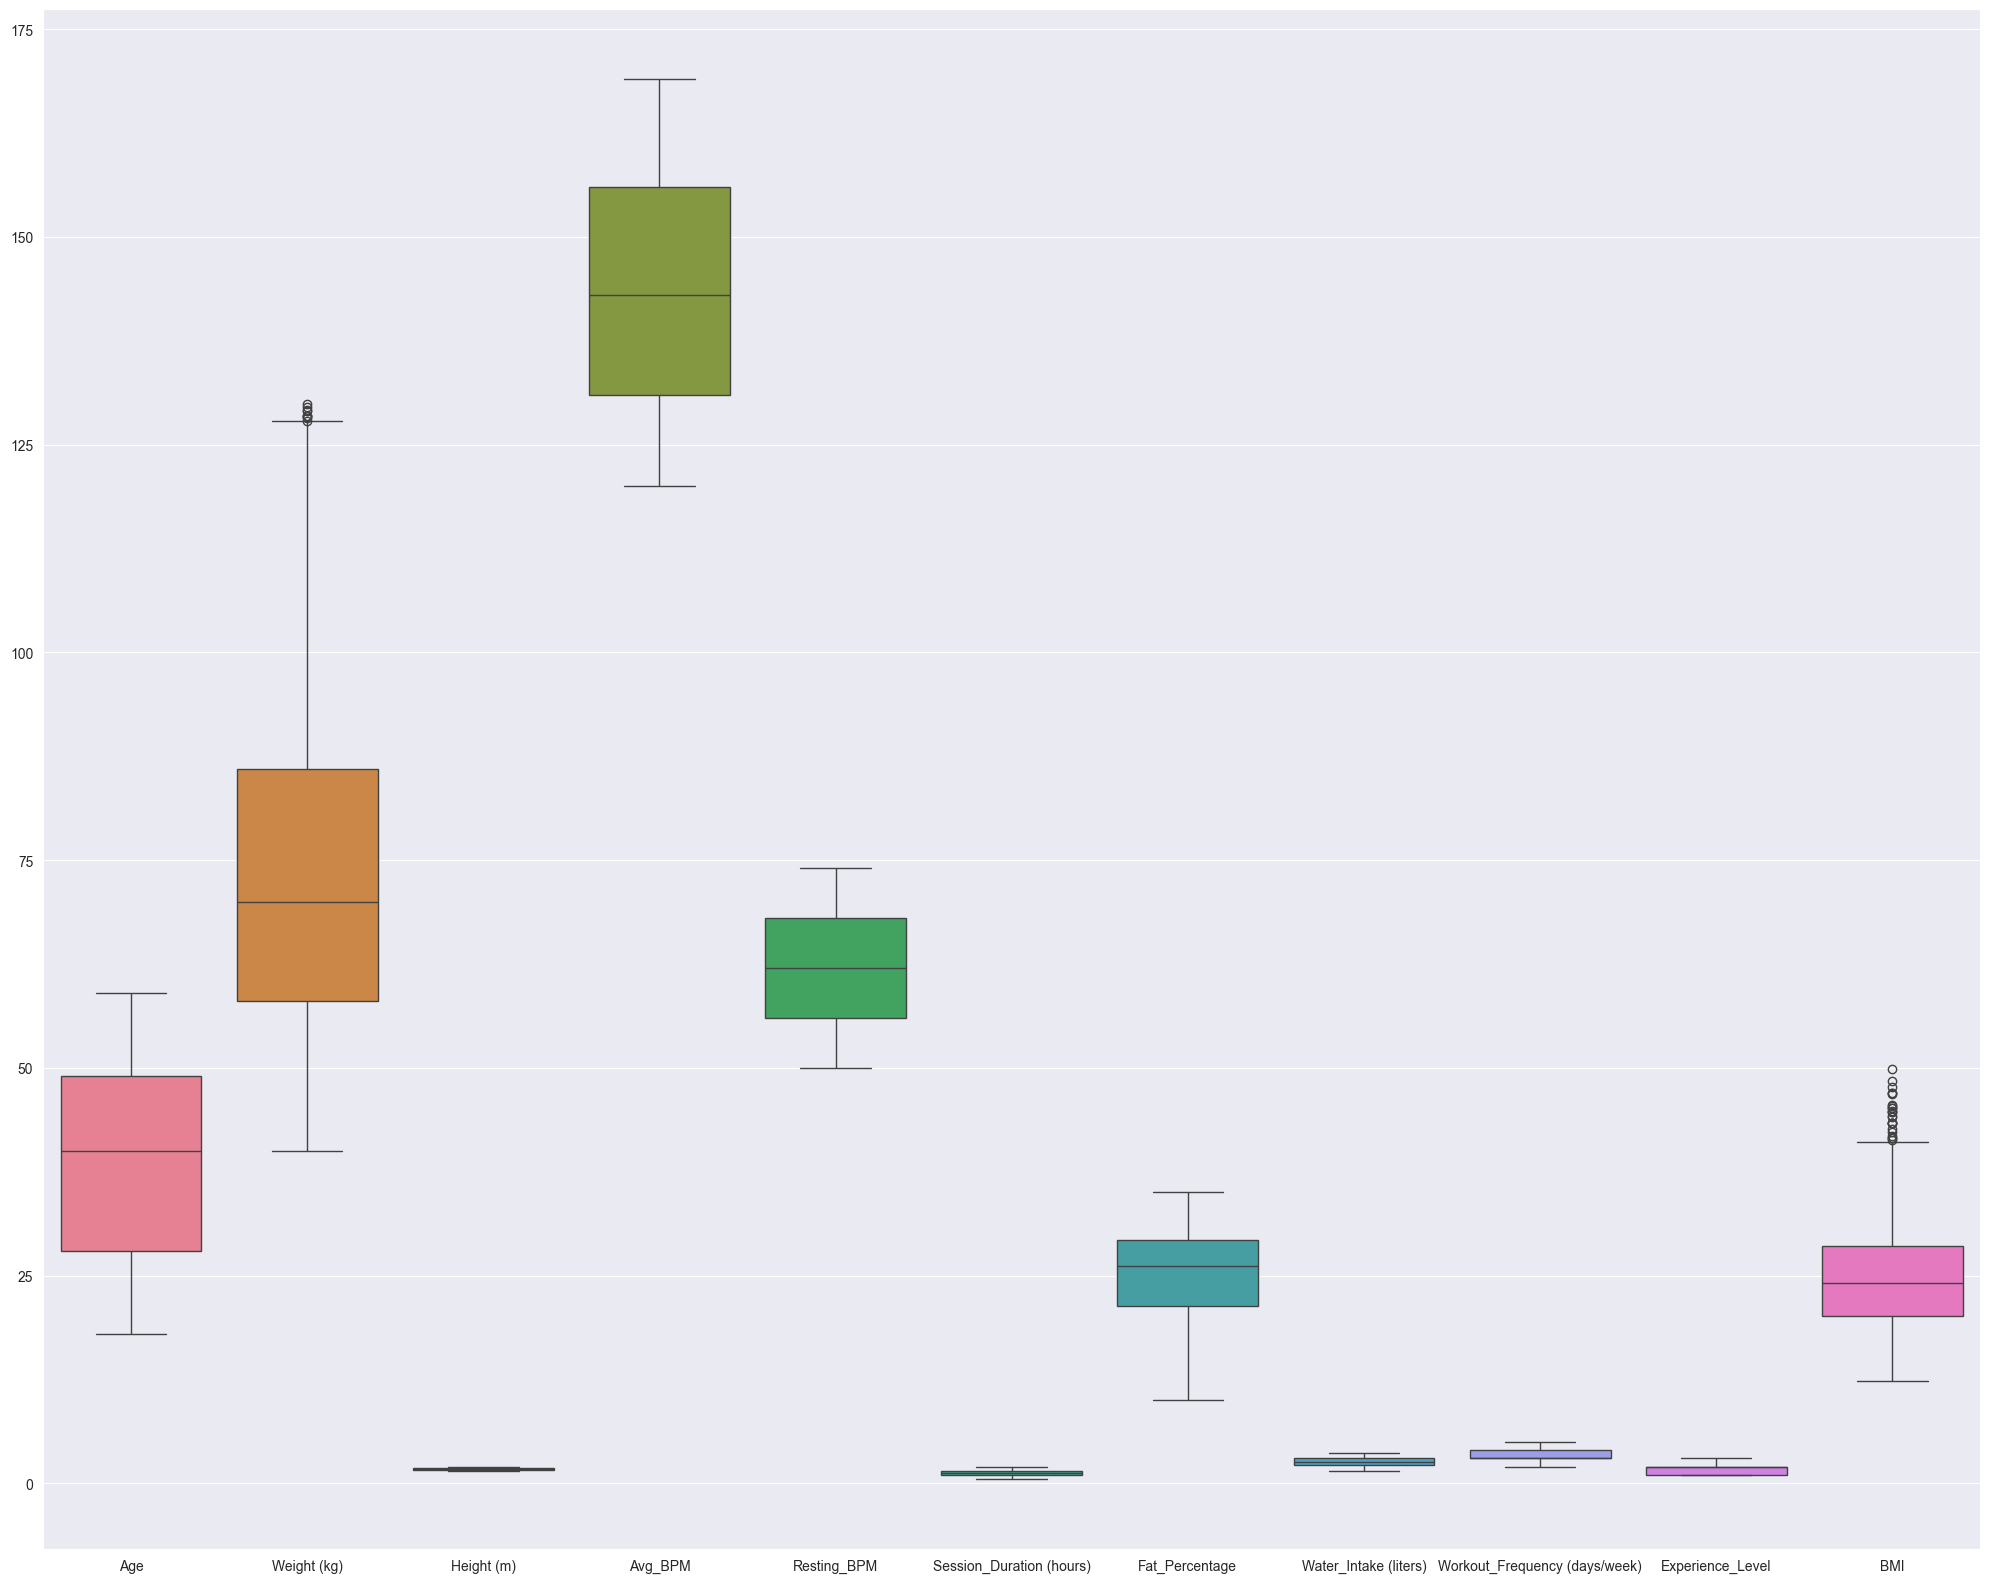

In [11]:
#finding outliers using graphical representation
plt.figure(figsize=(25, 20))
sb.boxplot(gym_dataset_copy)
plt.show()

In [12]:
#finding and removing outliers using IQR method

def remove_outliers_iqr(df):
    df_clean = df.copy()

    numeric_cols = df_clean.select_dtypes(include=['number']).columns

    for col in numeric_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        limit_inf = Q1 - 1.5 * IQR
        limit_sup = Q3 + 1.5 * IQR

        before_count = df_clean.shape[0]
        df_clean = df_clean[(df_clean[col] >= limit_inf) & (df_clean[col] <= limit_sup)]
        after_count = df_clean.shape[0]

        removed = before_count - after_count
        if removed > 0:
            print(f"Removed {removed} values out of {col}.")

    return df_clean

gym_dataset_cleaned = remove_outliers_iqr(gym_dataset_copy)

Removed 9 values out of Weight (kg).
Removed 23 values out of BMI.


### Duplicate Values

In [13]:
#duplicate values elimination

duplicates = gym_dataset_cleaned[gym_dataset_cleaned.duplicated()]

if len(duplicates) > 0:
    gym_dataset_cleaned = gym_dataset_cleaned.drop_duplicates()
    print(f"{len(duplicates)} duplicates removed.")
else:
    print(f"No duplicates found.")

No duplicates found.


### Handling Missing Values

In [14]:
#checking if there are any missing values

print(gym_dataset_cleaned.isnull().sum())

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64


**No missing values => No action required**